In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [39]:
matches = pd.read_csv(
    '/content/drive/MyDrive/worldcup_predictor/results.csv',
    parse_dates=['date']
)
rankings = pd.read_csv(
    '/content/drive/MyDrive/worldcup_predictor/fifa_ranking-2024-06-20.csv',
    parse_dates=['rank_date']
)

print(matches.shape)
print(rankings.shape)

(49477, 9)
(67472, 8)


In [40]:
# 1. Fix Inconsistent Names
name_fixes = {
    'United States': 'USA',
    'South Korea':   'Korea Republic',
    'North Korea':   'Korea DPR',
    'Iran':          'IR Iran',
    'Ivory Coast':   "Côte d'Ivoire",
    'China':         'China PR',
    'Czech Republic':'Czechia',
    'DR Congo':      'Congo DR',
    'Cape Verde':    'Cabo Verde',
    'Kyrgyzstan':    'Kyrgyz Republic',
    'Taiwan':        'Chinese Taipei',
}

matches['home_team'] = matches['home_team'].replace(name_fixes)
matches['away_team'] = matches['away_team'].replace(name_fixes)

In [41]:
# 2. Verify what's missing before the join
match_teams   = set(matches.home_team) | set(matches.away_team)
rank_teams    = set(rankings.country_full)
still_missing = sorted(match_teams - rank_teams)
print("still missing:", len(still_missing))
for name in still_missing:
    print(name)

still missing: 131
Abkhazia
Alderney
Ambazonia
Andalusia
Arameans Suryoye
Artsakh
Asturias
Aymara
Barawa
Basque Country
Biafra
Bonaire
Brittany
Brunei
Canary Islands
Cascadia
Catalonia
Central Spain
Chagos Islands
Chameria
Chechnya
Cilento
Corsica
County of Nice
Crimea
Curaçao
Darfur
Donetsk PR
Délvidék
East Turkestan
Elba Island
Ellan Vannin
Falkland Islands
Felvidék
Franconia
French Guiana
Frøya
Galicia
Gambia
German DR
Gotland
Gozo
Greenland
Guadeloupe
Guernsey
Găgăuzia
Hitra
Hmong
Iraqi Kurdistan
Isle of Man
Isle of Wight
Jersey
Kabylia
Kernow
Kiribati
Kurdistan
Kárpátalja
Luhansk PR
Madrid
Manchukuo
Mapuche
Marshall Islands
Martinique
Matabeleland
Maule Sur
Mayotte
Menorca
Micronesia
Monaco
Niue
North Vietnam
Northern Cyprus
Northern Mariana Islands
Occitania
Orkney
Padania
Palau
Panjab
Parishes of Jersey
Provence
Quebec
Raetia
Republic of St. Pauli
Rhodes
Romani people
Ryūkyū
Réunion
Saare County
Saarland
Saint Barthélemy
Saint Helena
Saint Kitts and Nevis
Saint Lucia
Saint Marti

In [42]:
# 3. Join data
rk = rankings[['rank_date','country_full','rank','total_points']].sort_values('rank_date')
matches = matches.sort_values('date')

m = pd.merge_asof(
    matches,
    rk.rename(columns={'country_full':'home_team','rank':'home_rank','total_points':'home_pts'}),
    left_on='date', right_on='rank_date', by='home_team', direction='backward'
).drop(columns='rank_date')

m = pd.merge_asof(
    m.sort_values('date'),
    rk.rename(columns={'country_full':'away_team','rank':'away_rank','total_points':'away_pts'}),
    left_on='date', right_on='rank_date', by='away_team', direction='backward'
).drop(columns='rank_date')

In [43]:
# 4. Verify if join worked for important teams
teams_to_check = ['USA', 'Korea Republic', 'IR Iran', "Côte d'Ivoire",
                  'Cabo Verde', 'Korea DPR', 'China PR', 'Czechia', 'Congo DR']

for team in teams_to_check:
    subset = m[(m.home_team == team) | (m.away_team == team)]
    nan_count = subset[['home_rank','away_rank']].isna().sum().sum()
    print(f"{team:20s}  matches: {len(subset):4d}   NaN ranks: {nan_count}")

USA                   matches:  793   NaN ranks: 476
Korea Republic        matches: 1010   NaN ranks: 982
IR Iran               matches:  615   NaN ranks: 359
Côte d'Ivoire         matches:  639   NaN ranks: 526
Cabo Verde            matches:  238   NaN ranks: 94
Korea DPR             matches:  390   NaN ranks: 276
China PR              matches:  702   NaN ranks: 579
Czechia               matches:  363   NaN ranks: 4
Congo DR              matches:  527   NaN ranks: 463


In [44]:
# Check for Korea Republic
korea = m[(m.home_team == 'Korea Republic') | (m.away_team == 'Korea Republic')]
print("all matches:", len(korea))
print("pre-1993:", len(korea[korea.date < '1993-01-01']))
print("post-1993:", len(korea[korea.date >= '1993-01-01']))

# Check for how many NaNs remain post-1993 for Korea
korea_post = korea[korea.date >= '1993-01-01']
print("post-1993 NaN ranks:", korea_post[['home_rank','away_rank']].isna().sum().sum())

all matches: 1010
pre-1993: 487
post-1993: 523
post-1993 NaN ranks: 8


In [45]:
# 5. Drop rows that can't be used
print("\nbefore drop:", len(m))
m = m.dropna(subset=['home_rank','away_rank'])
m = m.dropna(subset=['home_score','away_score'])
print("after drop: ", len(m))



before drop: 49477
after drop:  27608


In [46]:
# BASELINE and baseline accuracy
m['result'] = np.select(
    [m.home_score > m.away_score, m.home_score < m.away_score],
    ['H', 'A'], default='D'
)

# BASELINE: lower rank number = better team, predict that team wins
m['baseline'] = np.where(m.home_rank < m.away_rank, 'H', 'A')
baseline_acc = (m.baseline == m.result).mean()
print(f"Baseline accuracy: {baseline_acc:.3f}")

Baseline accuracy: 0.554


In [47]:
# sort so we're always looking backwards in time
m = m.sort_values('date').reset_index(drop=True)

def recent_form(df, team_col, opponent_col, result_col, n=5):
    """
    For each row, calculate that team's win rate in their last n matches
    before this match date.
    """
    results = []
    for idx, row in df.iterrows():
        team    = row[team_col]
        date    = row['date']
        # find previous matches involving this team
        past = df[
            ((df[team_col] == team) | (df[opponent_col] == team)) &
            (df['date'] < date)
        ].tail(n)
        if len(past) == 0:
            results.append(np.nan)
            continue
        # count wins from this team's perspective
        wins = 0
        for _, pm in past.iterrows():
            if pm[team_col] == team and pm[result_col] == 'H':
                wins += 1
            elif pm[opponent_col] == team and pm[result_col] == 'A':
                wins += 1
        results.append(wins / len(past))
    return results

m['home_form'] = recent_form(m, 'home_team', 'away_team', 'result')
m['away_form'] = recent_form(m, 'away_team', 'home_team', 'result')

In [48]:
def recent_goal_diff(df, team_col, opponent_col, score_col_for, score_col_against, n=5):
    results = []
    for idx, row in df.iterrows():
        team = row[team_col]
        date = row['date']
        past = df[
            ((df[team_col] == team) | (df[opponent_col] == team)) &
            (df['date'] < date)
        ].tail(n)
        if len(past) == 0:
            results.append(np.nan)
            continue
        gd = 0
        for _, pm in past.iterrows():
            if pm[team_col] == team:
                gd += pm[score_col_for] - pm[score_col_against]
            else:
                gd += pm[score_col_against] - pm[score_col_for]
        results.append(gd / len(past))
    return results

m['home_gd'] = recent_goal_diff(m, 'home_team', 'away_team', 'home_score', 'away_score')
m['away_gd'] = recent_goal_diff(m, 'away_team', 'home_team', 'away_score', 'home_score')

In [49]:
# manually append matches after dataset cutoff (June 24 onwards)
def make_match(date, home, away, home_score, away_score):
    """Helper to create a match row with all required columns."""
    if home_score is None or away_score is None:
        result = None
    else:
        result = 'H' if home_score > away_score else ('A' if away_score > home_score else 'D')
    home_r = current_rankings.get(home, {})
    away_r = current_rankings.get(away, {})
    return {
        'date':       pd.Timestamp(date),
        'home_team':  home,
        'away_team':  away,
        'home_score': float(home_score) if home_score is not None else None,
        'away_score': float(away_score) if away_score is not None else None,
        'tournament': 'FIFA World Cup',
        'neutral':    True,
        'result':     result,
        'home_rank':  home_r.get('rank', 50),
        'away_rank':  away_r.get('rank', 50),
        'home_pts':   home_r.get('points', 1400.0),
        'away_pts':   away_r.get('points', 1400.0),
        'home_form':  None,
        'away_form':  None,
        'home_gd':    None,
        'away_gd':    None,
        'is_wc':      1,
        'baseline':   'H' if home_r.get('rank', 50) < away_r.get('rank', 50) else 'A',
    }

new_matches = pd.DataFrame([
    # ── group stage matchday 3 (June 24-27) ──────────────────────────────────
    make_match('2026-06-24', 'Mexico',        'Czechia',        3, 0),
    make_match('2026-06-24', 'Korea Republic','South Africa',   1, 0),
    make_match('2026-06-25', 'Switzerland',   'Canada',         2, 1),
    make_match('2026-06-25', 'Mexico',       'Ecuador',         2, 0),
    make_match('2026-06-26', 'France',        'Norway',         4, 1),
    make_match('2026-06-26', 'Senegal',       'Iraq',           5, 0),
    make_match('2026-06-27', 'Argentina',     'Jordan',         3, 1),
    make_match('2026-06-27', 'Austria',       'Algeria',        3, 3),
    make_match('2026-06-27', 'Colombia',      'Portugal',       0, 0),
    make_match('2026-06-27', 'Congo DR',      'Uzbekistan',     3, 1),
    make_match('2026-06-27', 'England',       'Panama',         2, 0),
    make_match('2026-06-27', 'Croatia',       'Ghana',          2, 1),
    # ── round of 32 (June 28 - July 3) ───────────────────────────────────────
    make_match('2026-06-28', 'Canada',        'South Africa',   1, 0),
    make_match('2026-06-29', 'Brazil',        'Japan',          2, 1),
    make_match('2026-06-29', 'Germany',       'Paraguay',       1, 1),  # Paraguay won pens
    make_match('2026-06-29', 'Netherlands',   'Morocco',        1, 1),  # Morocco won pens
    make_match('2026-06-30', 'Norway',        "Côte d'Ivoire",  2, 1),
    make_match('2026-06-30', 'France',        'Sweden',         3, 0),
    make_match('2026-06-30', 'Mexico',        'Ecuador',        2, 0),
    make_match('2026-07-01', 'England',       'Congo DR',       2, 1),
    make_match('2026-07-01', 'Belgium',       'Senegal',        3, 2),
    make_match('2026-07-01', 'USA',           'Bosnia and Herzegovina', 2, 0),
    make_match('2026-07-02', 'Spain',         'Austria',        3, 0),
    make_match('2026-07-02', 'Portugal',      'Croatia',        2, 1),
    make_match('2026-07-02', 'Switzerland',   'Algeria',        3, 0),
    make_match('2026-07-03', 'Argentina',     'Cabo Verde',     3, 2),
    make_match('2026-07-03', 'Egypt',         'Australia',      1, 1),  # Egypt won pens
    make_match('2026-07-03', 'Colombia',      'Ghana',          1, 0),
    # ── round of 16 (completed so far) ───────────────────────────────────────
    make_match('2026-07-04', 'Morocco',       'Canada',         3, 0),
    make_match('2026-07-04', 'France',        'Paraguay',       1, 0),
    make_match('2026-07-05', 'Brazil',        'Norway',         1, 2),
    make_match('2026-07-06', 'Portugal',      'Spain',          None, None),  # upcoming
    make_match('2026-07-06', 'USA',           'Belgium',        None, None),  # upcoming
])

# drop upcoming matches
new_matches = new_matches.dropna(subset=['home_score', 'away_score'])

# append and re-sort
m = pd.concat([m, new_matches], ignore_index=True).sort_values('date').reset_index(drop=True)
print(f"Dataset now contains {len(m)} matches, latest: {m['date'].max().date()}")

Dataset now contains 27639 matches, latest: 2026-07-05


/tmp/ipykernel_18136/1916595985.py:74: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  m = pd.concat([m, new_matches], ignore_index=True).sort_values('date').reset_index(drop=True)


In [50]:
# Implement Features
m['rank_diff'] = m.home_rank - m.away_rank   # positive = home team is worse ranked
m['pts_diff']  = m.home_pts  - m.away_pts    # positive = home team has more points
m['neutral']   = m['neutral'].astype(int)    # 1 if neutral venue, 0 if home advantage
wc_tournaments = ['FIFA World Cup', 'FIFA World Cup qualification']
m['is_wc'] = m['tournament'].isin(wc_tournaments).astype(int)

features = ['rank_diff', 'pts_diff', 'neutral',
            'home_form', 'away_form', 'home_gd', 'away_gd', 'is_wc']

In [51]:
# time-based split
train = m[m.date <  '2018-01-01']
test  = m[m.date >= '2018-01-01']

print(f"Training rows: {len(train)}")
print(f"Test rows:     {len(test)}")

Training rows: 20215
Test rows:     7424


In [52]:
# Train using random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
)
clf.fit(train[features], train['result'])


RandomForestClassifier(n_estimators=300, random_state=42)

In [57]:
# Evaluation
pred = clf.predict(test[features])

model_acc    = accuracy_score(test['result'], pred)
baseline_acc = (m[m.date >= '2018-01-01']['baseline'] ==
                m[m.date >= '2018-01-01']['result']).mean()
# Baseline accuracy vs Model Accuracy
print(f"\nBaseline accuracy (test set): {baseline_acc:.3f}")
print(f"Model accuracy   (test set): {model_acc:.3f}")
print(f"Improvement: +{(model_acc - baseline_acc):.3f}")
print()
print(classification_report(test['result'], pred))


Baseline accuracy (test set): 0.578
Model accuracy   (test set): 0.566
Improvement: +-0.013

              precision    recall  f1-score   support

           A       0.56      0.51      0.54      2135
           D       0.30      0.12      0.17      1757
           H       0.61      0.82      0.70      3532

    accuracy                           0.57      7424
   macro avg       0.49      0.48      0.47      7424
weighted avg       0.52      0.57      0.53      7424



In [53]:
# ── current FIFA rankings (June 2026) ────────────────────────────────────────
# source: https://inside.fifa.com/fifa-world-ranking/men
current_rankings = {
    'France':          {'rank': 1,  'points': 1916.24},
    'Argentina':       {'rank': 2,  'points': 1913.71},
    'Spain':           {'rank': 3,  'points': 1892.28},
    'England':         {'rank': 4,  'points': 1850.97},
    'Brazil':          {'rank': 5,  'points': 1804.92},
    'Morocco':         {'rank': 6,  'points': 1803.99},
    'Portugal':        {'rank': 7,  'points': 1787.85},
    'Netherlands':     {'rank': 8,  'points': 1775.54},
    'Belgium':         {'rank': 9,  'points': 1756.51},
    'Mexico':          {'rank': 10, 'points': 1754.30},
    'Colombia':        {'rank': 11, 'points': 1739.89},
    'Germany':         {'rank': 12, 'points': 1726.22},
    'Croatia':         {'rank': 13, 'points': 1723.05},
    'Italy':           {'rank': 14, 'points': 1704.73},
    'Switzerland':     {'rank': 15, 'points': 1696.30},
    'USA':             {'rank': 16, 'points': 1690.33},
    'Japan':           {'rank': 17, 'points': 1673.68},
    'Senegal':         {'rank': 18, 'points': 1653.43},
    'Uruguay':         {'rank': 19, 'points': 1634.70},
    'Denmark':         {'rank': 20, 'points': 1619.47},
    'Norway':          {'rank': 21, 'points': 1617.67},
    'IR Iran':         {'rank': 22, 'points': 1609.85},
    'Austria':         {'rank': 23, 'points': 1598.82},
    'Egypt':           {'rank': 24, 'points': 1597.04},
    'Ecuador':         {'rank': 25, 'points': 1592.59},
    'Nigeria':         {'rank': 26, 'points': 1585.02},
    'Turkey':         {'rank': 27, 'points': 1582.54},
    'Australia':       {'rank': 28, 'points': 1581.51},
    'Algeria':         {'rank': 29, 'points': 1576.80},
    'Canada':          {'rank': 30, 'points': 1571.34},
    "Côte d'Ivoire":   {'rank': 31, 'points': 1565.47},
    'Korea Republic':  {'rank': 32, 'points': 1558.72},
    'Ukraine':         {'rank': 33, 'points': 1549.29},
    'Paraguay':        {'rank': 34, 'points': 1542.48},
}

def get_recent_stats(team, n=5):
    """Get a team's recent form and goal difference from match history."""
    past = m[
        (m.home_team == team) | (m.away_team == team)
    ].tail(n)

    if len(past) == 0:
        return 0.5, 0.0   # neutral defaults if no history

    wins, gd = 0, 0
    for _, row in past.iterrows():
        if row.home_team == team:
            wins += 1 if row.result == 'H' else 0
            gd   += row.home_score - row.away_score
        else:
            wins += 1 if row.result == 'A' else 0
            gd   += row.away_score - row.home_score

    return wins / len(past), gd / len(past)

def predict_match(home_team, away_team, neutral=False):
    """
    Predict the outcome of a match between two teams.
    Returns win/draw/loss probabilities.
    """
    # check if both teams exist in the rankings dict
    missing = [t for t in [home_team, away_team] if t not in current_rankings]
    if missing:
        print(f"Teams not found in current_rankings: {missing}")
        print(f"Available teams: {sorted(current_rankings.keys())}")
        return

    home = current_rankings[home_team]
    away = current_rankings[away_team]

    home_form, home_gd = get_recent_stats(home_team)
    away_form, away_gd = get_recent_stats(away_team)

    features_dict = {
        'rank_diff':  [home['rank']   - away['rank']],
        'pts_diff':   [home['points'] - away['points']],
        'neutral':    [int(neutral)],
        'home_form':  [home_form],
        'away_form':  [away_form],
        'home_gd':    [home_gd],
        'away_gd':    [away_gd],
        'is_wc':      [1], # always 1, just for this WC
    }

    X = pd.DataFrame(features_dict)
    proba = clf.predict_proba(X)[0]
    classes = clf.classes_   # ['A', 'D', 'H']
    probs = dict(zip(classes, proba))

    # display
    print(f"\n{'='*40}")
    print(f"  {home_team} vs {away_team}")
    print(f"  {'(neutral venue)' if neutral else '(home advantage)'}")
    print(f"{'='*40}")
    print(f"  {home_team} win:  {probs['H']:.1%}")
    print(f"  Draw:           {probs['D']:.1%}")
    print(f"  {away_team} win:  {probs['A']:.1%}")
    print(f"\n  Prediction: ", end="")

    best = max(probs, key=probs.get)
    if best == 'H':   print(f"{home_team} win")
    elif best == 'A': print(f"{away_team} win")
    else:             print("Draw")

    return probs

# Tests ────────────────────────────────────────────────────────────────────────

predict_match('Portugal', 'Colombia', neutral=True)
predict_match('Mexico', 'England', neutral=False)
predict_match('Spain', 'Portugal', neutral=True)


  Portugal vs Colombia
  (neutral venue)
  Portugal win:  28.7%
  Draw:           44.0%
  Colombia win:  27.3%

  Prediction: Draw

  Mexico vs England
  (home advantage)
  Mexico win:  39.7%
  Draw:           36.7%
  England win:  23.7%

  Prediction: Mexico win

  Spain vs Portugal
  (neutral venue)
  Spain win:  37.7%
  Draw:           40.3%
  Portugal win:  22.0%

  Prediction: Draw


{'A': np.float64(0.22),
 'D': np.float64(0.4033333333333333),
 'H': np.float64(0.37666666666666665)}

In [54]:
# verify name matches in match data
for team in current_rankings:
    count = len(m[(m.home_team == team) | (m.away_team == team)])
    if count == 0:
        print(f"WARNING — no matches found for: {team}")

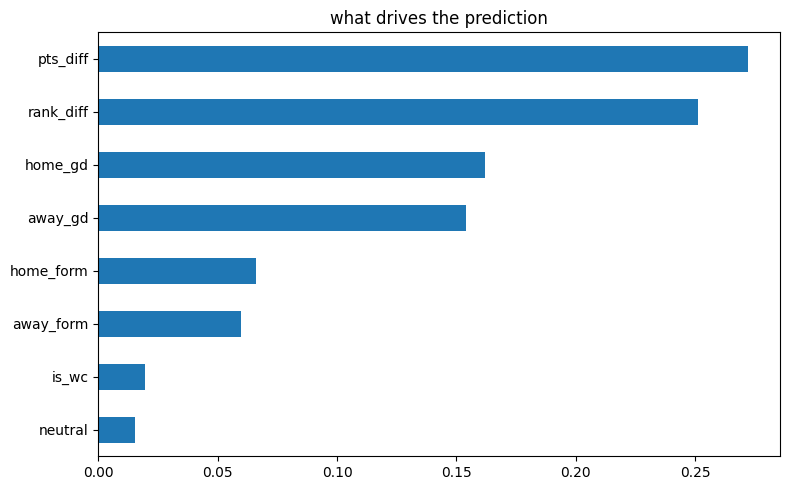

In [55]:
feat_imp = pd.Series(
    clf.feature_importances_,
    index=features
).sort_values()

feat_imp.plot(
    kind='barh',
    figsize=(8, 5),
    title='what drives the prediction'
)
plt.tight_layout()
plt.show()

In [56]:
print("Latest match in dataset:", m['date'].max())
print("\nLatest matches:")
print(m.tail(10)[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament']])

Latest match in dataset: 2026-07-05 00:00:00

Latest matches:
            date    home_team               away_team  home_score  away_score  \
27629 2026-07-01          USA  Bosnia and Herzegovina         2.0         0.0   
27630 2026-07-02     Portugal                 Croatia         2.0         1.0   
27631 2026-07-02        Spain                 Austria         3.0         0.0   
27632 2026-07-02  Switzerland                 Algeria         3.0         0.0   
27633 2026-07-03        Egypt               Australia         1.0         1.0   
27634 2026-07-03    Argentina              Cabo Verde         3.0         2.0   
27635 2026-07-03     Colombia                   Ghana         1.0         0.0   
27636 2026-07-04       France                Paraguay         1.0         0.0   
27637 2026-07-04      Morocco                  Canada         3.0         0.0   
27638 2026-07-05       Brazil                  Norway         1.0         2.0   

           tournament  
27629  FIFA World Cup 